# Projeto Avaliativo - Módulo 1 - Semana 14
 
# Predicting Life Expectancy Using the WHO Health Inequality Data Repository (HIDR)

## Beyond the Numbers: Predicting Life Expectancy from Global Health Inequalities

**Author:** Ananda Christina Staats Pires

**Institution:** Fundamentos de Dados, Programação e Análise Preditiva com Python, SENAI - Programa SCTEC

**Project Type:** End-to-End Machine Learning Regression Pipeline

**Date:** July 2026

## 1.1 Introduction

Life expectancy is a key indicator of population health and socioeconomic development. It reflects the combined influence of healthcare access, disease burden, environmental exposures, behavioural risk factors, and social determinants of health.

This project develops a supervised machine learning regression pipeline to predict life expectancy using publicly available indicators from the World Health Organization (WHO) Health Inequality Data Repository (HIDR).

Unlike conventional machine learning datasets containing a single pre-processed table, this project integrates multiple WHO thematic datasets into a unified country-year analytical dataset. The workflow includes data acquisition, indicator screening, dataset harmonization, exploratory data analysis, feature preparation, regression modelling, and model evaluation.

The final objective is to investigate how multidimensional health inequality indicators contribute to variations in life expectancy across countries and over time.

## 1.2 Problem Definition

Life expectancy summarizes the overall health status of populations and is widely used for monitoring health inequalities and supporting evidence-based policy decisions.

The objective of this project is to develop a regression model capable of predicting life expectancy using indicators representing socioeconomic conditions, environmental exposures, behavioural risk factors, and healthcare system characteristics.

By integrating multiple domains of population health, the model aims to provide an interpretable framework for understanding the contribution of different determinants to population health outcomes.

## 1.3 Project Objectives

### General Objective

Develop an end-to-end machine learning regression pipeline to predict life expectancy using global health indicators from the WHO Health Inequality Data Repository.

### Specific Objectives

- Retrieve health inequality indicators through the WHO HIDR API.
- Screen and select epidemiologically relevant predictors.
- Harmonize heterogeneous datasets into a country-year analytical structure.
- Perform exploratory data analysis and assess data quality.
- Prepare features for regression modelling.
- Train and evaluate predictive models.
- Document the complete workflow following reproducible data science practices.

## 1.4 Data Source


The data used in this project were obtained from the **World Health Organization (WHO) Health Inequality Data Repository (HIDR)**.

The HIDR is a comprehensive repository of harmonized international health indicators covering multiple dimensions of population health, including health outcomes, healthcare systems, environmental conditions, behavioural risk factors, and socioeconomic determinants.

All datasets were accessed programmatically through the official WHO API, ensuring reproducibility and facilitating future updates as new data become available.

### Citation

> World Health Organization. *Health Inequality Data Repository API*. Geneva: WHO, 2025. Available at: https://www.who.int/data/inequality-monitor/data. Accessed on 09 July 2026.

# 1.5 Project Structure

This project follows a modular and reproducible architecture in which reusable functions are implemented inside the `src/` package, while the notebook focuses exclusively on the analytical workflow.

Separating data processing, visualization, preprocessing, and modelling into independent modules improves code readability, maintainability, and reproducibility.

The project is organized as follows:

- `config.py` — project configuration, directory structure, and file paths.
- `dataset.py` — dataset catalog, download utilities, caching, and data persistence.
- `feature_selection.py` — indicator screening and feature selection.
- `harmonization.py` — data harmonization and analytical dataset construction.
- `features.py` — preprocessing, feature engineering, and preparation of the modelling dataset.
- `plots.py` — reusable visualization functions.
- `modeling.py` — model training and evaluation.

# 1.6 Configure Project Environment

Before running the analysis, the notebook automatically locates the project root directory and adds it to the Python path.

This allows all reusable modules inside the `src/` package to be imported consistently regardless of the current working directory.

In [50]:
# =============================================================================
# Configure project environment
# =============================================================================

import os
import sys
from pathlib import Path

project_root = Path.cwd()

while not (project_root / "src").exists():

    if project_root == project_root.parent:
        raise RuntimeError("Project root not found.")

    project_root = project_root.parent

os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)
print("Current directory:", Path.cwd())
print("src exists:", (project_root / "src").exists())
print("sys.path[0]:", sys.path[0])

Project root: /Users/anandastaats/who-life-expectancy_prediction
Current directory: /Users/anandastaats/who-life-expectancy_prediction
src exists: True
sys.path[0]: /Users/anandastaats/who-life-expectancy_prediction


# 1.7 Import Libraries

The project combines standard scientific Python libraries with custom reusable modules implemented inside the `src` package.

This modular design keeps the notebook concise while centralizing reusable functionality into dedicated source files, improving readability, consistency, and long-term maintenance.

In [51]:
# =============================================================================
# Standard libraries
# =============================================================================

import numpy as np
import pandas as pd

from IPython.display import display

# =============================================================================
# Display configuration
# =============================================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# =============================================================================
# Project modules
# =============================================================================

from src.dataset import (
    list_hidr_datasets,
    load_hidr_dataset,
    dataset_summary,
    save_processed_dataset,
    load_processed_dataset,
    save_final_dataset,
    load_final_dataset,
)

from src.feature_selection import (
    calculate_indicator_coverage,
    get_top_indicators,
    display_screening_results,
    extract_selected_indicators,
)

from src.harmonization import (
    inspect_reporting_dimensions,
    aggregate_subgroups,
    reshape_to_wide,
    merge_datasets,
    rename_variables,
    dataset_quality_summary,
)

from src.features import (
    summarize_data_coverage,
    temporal_coverage,
    remove_missing_target,
    median_imputation,
    summarize_outliers,
    add_features,
    high_correlation_pairs,
    prepare_model_dataset,
    select_final_columns,
    high_correlation_pairs,
)

from src.plots import (
    _savefig,
    plot_indicator_coverage,
    plot_temporal_coverage,
    plot_missing_values,
    plot_histogram,
    plot_correlation_heatmap,
    plot_boxplots,
    plot_observed_vs_predicted,
    plot_residuals,   
)

from src.modeling.train import (
    save_model,
    load_model,
    save_metrics,
    load_metrics,
)

## 1.8. Download WHO HIDR Datasets

The WHO HIDR provides a comprehensive collection of international datasets covering multiple dimensions of population health, including mortality, healthcare systems, environmental conditions, behavioral risk factors, and socioeconomic development.

Rather than relying on a single dataset, this project integrates information from multiple WHO repositories to construct a unified analytical dataset for predicting life expectancy.

The workflow below first displays the datasets currently available within the repository, then downloads the selected datasets and stores them locally. Downloaded files are automatically cached, ensuring reproducibility while reducing execution time in future analyses.

In [52]:
# =============================================================================
# Available WHO HIDR datasets
# =============================================================================

list_hidr_datasets()

,dataset_id,dataset_name,topic
0,rep_oecd_ah,Adult health,Adult health
1,rep_gho_tobacco,Tobacco,Adult health
2,rep_dhs_ahn,Adult health and nutrition,Adult health
3,rep_gho_alcohol,Alcohol,Adult health
4,rep_gho_ncd,Noncommunicable diseases and risk factors,Adult health
5,rep_gdl2,Development indicators,Beyond the health sector
6,rep_gdl1,Development indices,Beyond the health sector
7,rep_mpi,Multidimensional Poverty Index,Beyond the health sector
8,rep_wb,Health determinants (World Bank),Beyond the health sector
9,rep_ghe_yld_sex,Years lived with disability,Burden of disease


### Selected datasets

The following datasets were selected to capture complementary determinants of life expectancy, including mortality, healthcare resources, noncommunicable diseases, environmental conditions, sanitation, poverty, education, and behavioral risk factors.

In [53]:
# =============================================================================
# Selected WHO HIDR datasets
# =============================================================================

selected_datasets = {

    "mortality": "rep_gho_mortality",
    "healthcare": "rep_gho_hc",
    "ncd": "rep_gho_ncd",
    "tobacco": "rep_gho_tobacco",
    "alcohol": "rep_gho_alcohol",
    "environment": "rep_gho_env",
    "wash": "rep_wash",
    "poverty": "rep_mpi",
    "world_bank": "rep_wb",
    "development": "rep_gdl2",

}

# =============================================================================
# Download selected datasets
# =============================================================================
datasets = {
    name: load_hidr_dataset(dataset_id)
    for name, dataset_id in selected_datasets.items()
}

Loading cached dataset: rep_gho_mortality
Loading cached dataset: rep_gho_hc
Loading cached dataset: rep_gho_ncd
Loading cached dataset: rep_gho_tobacco
Loading cached dataset: rep_gho_alcohol
Loading cached dataset: rep_gho_env
Loading cached dataset: rep_wash
Loading cached dataset: rep_mpi
Loading cached dataset: rep_wb
Loading cached dataset: rep_gdl2


In [54]:
# =============================================================================
# Summarize downloaded datasets
# =============================================================================

dataset_summary(datasets)

,Dataset,Rows,Columns,Memory (MB)
0,ncd,625089,24,498.30
1,development,608520,24,519.95
2,world_bank,350088,24,312.44
3,mortality,166980,24,132.40
4,environment,138282,24,116.67
5,wash,136907,24,103.48
6,healthcare,99976,24,82.14
7,alcohol,68901,24,54.08
8,tobacco,21882,24,17.60
9,poverty,8994,24,7.34


### Interpretation

Ten thematic datasets were successfully retrieved from the WHO HIDR.

Together, these datasets provide complementary information describing demographic, socioeconomic, environmental, behavioral, and healthcare determinants of population health.

Using multiple data sources enables the construction of a comprehensive analytical dataset capable of capturing diverse factors associated with life expectancy while maintaining a transparent and reproducible data acquisition workflow.

## 1.9 Indicator Screening

The downloaded WHO datasets contain hundreds of indicators with varying geographical coverage, temporal availability, and completeness.

Before selecting predictors for the machine learning model, an indicator screening procedure was performed to quantify data availability across countries and years.

This preliminary assessment helps identify variables with sufficient coverage while supporting transparent and reproducible feature selection.

In [55]:
# =============================================================================
# Calculate indicator coverage
# =============================================================================

coverage = calculate_indicator_coverage(datasets)

coverage.head()

,dataset,indicator_name,countries,years,observations,missing
0,mortality,Adult mortality rate (probability of dying bet...,185,22,8140,0.00
1,mortality,"Air pollution attributable DALYs, ambient (per...",183,1,366,0.00
2,mortality,"Air pollution attributable DALYs, ambient (per...",183,1,366,0.00
3,mortality,"Air pollution attributable DALYs, ambient (per...",183,1,366,0.00
4,mortality,"Air pollution attributable DALYs, ambient (per...",183,1,366,0.00


In [56]:
# =============================================================================
# Display best covered indicators from each dataset
# =============================================================================

display_screening_results(coverage,n=10)

Dataset: alcohol


,dataset,indicator_name,countries,years,observations,missing
234,alcohol,"Alcohol, abstainers in past 12 months (%)",194,21,7859,0.11
245,alcohol,"Alcohol, heavy episodic drinking in past 30 da...",194,21,7858,0.13
246,alcohol,"Alcohol, heavy episodic drinking in past 30 da...",194,21,7858,0.13
235,alcohol,"Alcohol, abstainers lifetime (%)",194,21,7854,0.18
237,alcohol,"Alcohol, consumers in past 12 months (age-stan...",194,21,7854,0.18
239,alcohol,"Alcohol, former drinkers (%)",194,21,7854,0.18
240,alcohol,"Alcohol, harmful use, 12 month prevalence (15+...",194,1,0,100.00
249,alcohol,"Alcohol, per capita consumption (15+ years, am...",191,21,7670,2.44
236,alcohol,"Alcohol, average daily intake among drinkers (...",189,21,7858,0.00
238,alcohol,"Alcohol, current drinkers (youth 15-19 years) (%)",189,2,756,0.00


Dataset: development


,dataset,indicator_name,countries,years,observations,missing
412,development,Expected years of schooling (children aged 6),164,33,55123,0.00
432,development,Life expectancy (years),164,33,55057,0.00
435,development,Mean years of schooling (population aged 25+),164,33,55023,0.00
413,development,Expected years of schooling (children aged 6) ...,164,23,37800,0.00
414,development,Expected years of schooling (children aged 6) ...,164,23,37799,0.00
436,development,Mean years of schooling (population aged 25+) ...,164,23,37749,0.00
437,development,Mean years of schooling (population aged 25+) ...,164,23,37738,0.00
433,development,Life expectancy (years) - Female,163,23,37310,0.00
434,development,Life expectancy (years) - Male,163,23,37310,0.00
422,development,Households with a phone (%),126,32,7587,0.03


Dataset: environment


...

,dataset,indicator_name,countries,years,observations,missing
231,tobacco,Tobacco: current cigarette smoking among adole...,191,19,356,6.81
220,tobacco,"Tobacco, current tobacco use among adolescents...",191,19,282,26.18
216,tobacco,"Tobacco, current tobacco smoking among adolesc...",191,19,208,45.55
224,tobacco,"Tobacco, daily cigarette smoking among adolesc...",191,19,54,85.86
228,tobacco,"Tobacco, daily tobacco smoking among adolescen...",191,19,14,96.34
217,tobacco,"Tobacco, current tobacco smoking among adults ...",190,17,276,27.37
221,tobacco,"Tobacco, current tobacco use among adults (sur...",190,17,210,44.74
232,tobacco,Tobacco: current cigarette smoking among adult...,190,17,210,44.74
229,tobacco,"Tobacco, daily tobacco smoking among adults (s...",190,17,195,48.68
225,tobacco,"Tobacco, daily cigarette smoking among adults ...",190,17,106,72.11


Dataset: wash


,dataset,indicator_name,countries,years,observations,missing
315,wash,Population using basic drinking water services...,173,25,8516,0.00
318,wash,Population using limited drinking water servic...,173,25,8516,0.00
324,wash,Population using unimproved drinking water ser...,173,25,8516,0.00
323,wash,Population using surface water (%),173,25,8278,0.00
317,wash,Population using basic sanitation services (%),171,25,8370,0.00
320,wash,Population using limited sanitation services (%),171,25,8370,0.00
325,wash,Population using unimproved sanitation service...,171,25,8370,0.00
314,wash,Population practising open defecation (%),171,25,8292,0.00
316,wash,Population using basic hygiene services (%),111,25,3346,0.00
326,wash,Population with no hygiene services (%),110,25,3460,0.00


Dataset: world_bank


,dataset,indicator_name,countries,years,observations,missing
379,world_bank,Land area where elevation is below 5 meters (%...,195,3,1170,0.00
387,world_bank,Population living in areas where elevation is ...,195,3,1170,0.00
384,world_bank,Over-age students in primary education (% of e...,193,50,8295,0.18
362,world_bank,"Educational attainment, at least completed low...",191,53,4233,0.12
364,world_bank,"Educational attainment, at least completed pri...",191,50,4010,0.00
388,world_bank,Primary completion rate (% of relevant age group),190,54,9595,0.03
366,world_bank,"Educational attainment, at least completed upp...",189,52,4156,0.00
354,world_bank,Children out of school (% of primary school age),188,54,7534,0.03
390,world_bank,Repeaters of primary education (% of total enr...,188,50,8542,0.00
382,world_bank,Lower secondary completion rate (% of relevant...,186,54,7726,0.05


### Interpretation

The screening results reveal considerable variability in data availability across the WHO repositories.

While some indicators provide extensive geographical and temporal coverage, others are available only for specific countries, years, or population groups.

Coverage was considered alongside epidemiological relevance, interpretability, and redundancy during feature selection. Indicators with broader availability maximize the number of country-year observations retained in the final analytical dataset, whereas highly relevant indicators with more limited coverage were evaluated individually to balance model performance and public health relevance.

## 1.10 Feature Selection

The objective of this study is to develop an interpretable machine learning model for predicting life expectancy using routinely available public health indicators.

Feature selection was therefore guided by domain knowledge rather than automated statistical procedures alone. Candidate predictors were selected according to four complementary criteria:

- epidemiological relevance;
- global data availability;
- low redundancy with other variables;
- interpretability for public health applications.

The final feature set represents multiple dimensions known to influence population health, including socioeconomic development, environmental conditions, behavioral risk factors, and healthcare access.

In [57]:
# =============================================================================
#  Define selected indicators for modelling
# =============================================================================

selected_features = {

    "development": [
        "Life expectancy (years) ",
        "Expected years of schooling (children aged 6)",
        "Mean years of schooling (population aged 25+)"
    ],

    "poverty": [
        "Multidimensional Poverty Index"
    ],

    "environment": [
        "Concentrations of fine particulate matter (PM2.5)",
        "Population with primary reliance on polluting fuels and technologies for cooking (%)"
    ],

    "wash": [
        "Population using safely managed drinking water services (%)",
        "Population using safely managed sanitation services (%)"
    ],

    "alcohol": [
        "Alcohol, consumers in past 12 months (age-standardized) (%)",
        "Alcohol, per capita consumption (15+ years, among drinkers only) (in litres of pure alcohol)"
    ],

    "tobacco": [
        "Tobacco, current tobacco use prevalence (model-based estimates, age-standardized) (%)"
    ],

    "ncd": [
        "Obesity prevalence among adults, BMI>=30 (age-standardized) (%)"
    ],

    "healthcare": [
        "Medical doctors (%)",
        "Diabetes treatment coverage (30+ years) (age-standardized) (%)",
        "Hypertension treatment coverage among adults aged 30-79 with hypertension (age-standardized) (%)"
    ]
}

In [58]:
# =============================================================================
# Extract selected indicators
# =============================================================================

selected_data = extract_selected_indicators(datasets, selected_features)


{
    name: df.shape
    for name, df in selected_data.items()
}

{'development': (165203, 24),
 'poverty': (4497, 24),
 'environment': (17052, 24),
 'wash': (8800, 24),
 'alcohol': (15730, 24),
 'tobacco': (2640, 24),
 'ncd': (12870, 24),
 'healthcare': (27732, 24)}

### Interpretation

The selected indicators cover complementary determinants of population health, including educational attainment, multidimensional poverty, environmental quality, sanitation, behavioral risk factors, obesity, and healthcare resources.

Together, these variables provide a multidimensional representation of the social, environmental, and healthcare factors associated with life expectancy while maintaining a relatively parsimonious feature set.

The extracted datasets preserve their original country-year structure and are now ready for harmonization into a single analytical dataset suitable for exploratory data analysis and predictive modelling.

## 1.11 Dataset Harmonization

The selected indicators originate from multiple WHO HIDR datasets. Although these datasets share a common structure, several indicators are reported separately for demographic or geographic subgroups such as sex, age, or place of residence.

To create a unified country-year analytical dataset suitable for machine learning, the selected indicators were harmonized through a standardized workflow consisting of four sequential steps:

1. inspection of reporting dimensions;
2. aggregation of subgroup-specific estimates;
3. transformation from long to wide format;
4. integration of all datasets into a single analytical dataset.

In [59]:
# =============================================================================
# Inspect reporting dimensions
# =============================================================================

inspect_reporting_dimensions(selected_data)

Dataset: development

Indicator: Expected years of schooling (children aged 6)


,dimension,subgroup,observations
335,Subnational region,Central,325
1409,Subnational region,South,243
1070,Subnational region,North,243
517,Subnational region,Eastern,132
1648,Subnational region,Western,132
...,...,...,...
521,Subnational region,Eastern Equatoria,13
1619,Subnational region,Warrap,13
934,Subnational region,Mary,13
1655,Subnational region,Western Equatoria,13



Indicator: Life expectancy (years) 


,dimension,subgroup,observations
335,Subnational region,Central,325
1069,Subnational region,North,243
1408,Subnational region,South,243
517,Subnational region,Eastern,132
1646,Subnational region,Western,132
...,...,...,...
847,Subnational region,Lebap,13
836,Subnational region,Lakes,13
1650,Subnational region,Western Bahr El Ghazal,13
1617,Subnational region,Warrap,13



Indicator: Mean years of schooling (population aged 25+)


...

,dimension,subgroup,observations
0,Sex,Female,6435
1,Sex,Male,6435



Indicator: Hypertension treatment coverage among adults aged 30-79 with hypertension (age-standardized) (%)


,dimension,subgroup,observations
0,Sex,Female,5850
1,Sex,Male,5850



Indicator: Medical doctors (%)


,dimension,subgroup,observations
0,Sex,Female,1581
1,Sex,Male,1581


### Interpretation

The inspection confirms that several indicators are reported for multiple demographic or geographic subgroups.

Since the predictive model operates at the country-year level, subgroup-specific estimates must be aggregated before integrating information across datasets.

In [60]:
# =============================================================================
# Aggregate subgroup estimates
# =============================================================================

aggregated_data, aggregation_summary = aggregate_subgroups(selected_data)

aggregation_summary

,dataset,indicator_name,observations_before,observations_after,reduction_percent
0,development,Expected years of schooling (children aged 6),55123,5057,90.80
1,development,Life expectancy (years),55057,5057,90.80
2,development,Mean years of schooling (population aged 25+),55023,5052,90.80
3,poverty,Multidimensional Poverty Index,4497,238,94.70
4,environment,Concentrations of fine particulate matter (PM2.5),3860,1950,49.50
5,environment,Population with primary reliance on polluting ...,13192,6596,50.00
6,wash,Population using safely managed drinking water...,4182,2091,50.00
7,wash,Population using safely managed sanitation ser...,4618,2309,50.00
8,alcohol,"Alcohol, consumers in past 12 months (age-stan...",7868,3934,50.00
9,alcohol,"Alcohol, per capita consumption (15+ years, am...",7862,3931,50.00


### Interpretation

Subgroup-specific estimates were aggregated into a single country-year observation using the mean estimate.

This procedure standardizes the reporting structure across indicators while preserving the overall information contained in the original WHO datasets.

In [61]:
# =============================================================================
# Transform datasets into wide format
# =============================================================================

wide_data = reshape_to_wide(aggregated_data)

{
    name: df.shape
    for name, df in wide_data.items()
}

{'development': (5057, 6),
 'poverty': (238, 4),
 'environment': (6636, 5),
 'wash': (2859, 5),
 'alcohol': (3934, 5),
 'tobacco': (1320, 4),
 'ncd': (6435, 4),
 'healthcare': (6571, 6)}

In [62]:
# =============================================================================
# Merge datasets
# =============================================================================

analytical_dataset = merge_datasets(wide_data)

analytical_dataset.shape

(6927, 18)

In [63]:
# =============================================================================
# Standardize variable names
# =============================================================================

analytical_dataset = rename_variables(analytical_dataset)

analytical_dataset.head()

,iso3,setting,date,expected_years_schooling,life_expectancy,mean_years_schooling,mpi,pm25,polluting_cooking_fuels,safe_drinking_water,safe_sanitation,alcohol_consumers,alcohol_consumption,tobacco_use,obesity_prevalence,diabetes_treatment,hypertension_treatment,medical_doctors
0,AFG,Afghanistan,1990,3.07,46.06,0.84,NaN,NaN,97.45,NaN,NaN,NaN,NaN,NaN,1.95,22.32,19.10,NaN
1,AFG,Afghanistan,1991,3.37,46.76,0.88,NaN,NaN,97.00,NaN,NaN,NaN,NaN,NaN,2.10,22.36,19.75,NaN
2,AFG,Afghanistan,1992,3.68,47.70,0.92,NaN,NaN,96.25,NaN,NaN,NaN,NaN,NaN,2.27,22.40,20.50,NaN
3,AFG,Afghanistan,1993,3.99,51.57,0.96,NaN,NaN,95.45,NaN,NaN,NaN,NaN,NaN,2.45,22.45,21.20,NaN
4,AFG,Afghanistan,1994,4.29,51.60,1.00,NaN,NaN,94.40,NaN,NaN,NaN,NaN,NaN,2.64,22.50,21.95,NaN


In [64]:
# =============================================================================
# Assess analytical dataset structure
# =============================================================================

dataset_quality_summary(analytical_dataset)

,Rows,Columns,Countries,Years,Missing values,Missing (%),Memory (MB)
0,6927,18,198,45,46172,37.03,1.58


### Interpretation

The harmonization process successfully transformed multiple WHO HIDR repositories into a unified country-year analytical dataset.

Each observation represents one country in one year, while columns represent selected health, socioeconomic, environmental, behavioural, and healthcare indicators.

This dataset constitutes the foundation for exploratory data analysis, where completeness, distributions, temporal coverage, and relationships between predictors and life expectancy will be evaluated.

In [65]:
# =============================================================================
# Saving dataset
# =============================================================================

save_processed_dataset(analytical_dataset)

Processed dataset saved: /Users/anandastaats/who-life-expectancy_prediction/data/processed/analytical_dataset.csv


## Phase 1 - Exploratory Data Analysis (EAD)

This phase aims to understand the structure and quality of the harmonized WHO dataset before any preprocessing.

The exploratory analysis focuses on:

- dataset structure and variable types;
- duplicate records and missing values;
- indicator availability across countries and years;
- temporal consistency of the data;
- definition of the modelling dataset;
- exploratory analysis of the target variable;
- relationships between predictors and life expectancy.

The objective is to establish an evidence-based foundation for the preprocessing and modelling stages.

## Dataset structure

The first quality assessment evaluates:

- variable names;
- data types;
- number of observations;
- numerical and categorical variables.

Correct data types are essential for subsequent statistical analysis and machine learning preprocessing.

In [66]:
# =============================================================================
# Load harmonized analytical dataset
# =============================================================================

df = load_processed_dataset()

print("=" * 70)
print("ANALYTICAL DATASET OVERVIEW")
print("=" * 70)

# =============================================================================
# Inspect dataset structure
# =============================================================================

print(f"Dataset shape: {df.shape}")

print("\nData types:")
display(df.dtypes)

print("\nFirst five observations:")
display(df.head())

# Calculate missing values
print("\nMissing values:")

missing_summary = (
    pd.DataFrame({
        "Missing values": df.isnull().sum(),
        "Percentage (%)": (df.isnull().mean() * 100).round(2)
    })
    .sort_values("Percentage (%)", ascending=False)
)

display(missing_summary)


# Calculate Descriptive statistics 
print("\nDescriptive statistics:")
display(df.describe().T)


# Complete duplicates

n_duplicates = df.duplicated().sum()

print(f"Complete duplicate rows: {n_duplicates}")

# Duplicate country-year observations

n_country_year = df.duplicated(
    subset=["iso3", "date"]
).sum()

print(f"Duplicate country-year observations: {n_country_year}")

if n_country_year > 0:
    display(
        df.loc[
            df.duplicated(
                subset=["iso3", "date"],
                keep=False
            )
        ].sort_values(["iso3", "date"])
    )

Loaded processed dataset: (6927, 18)
ANALYTICAL DATASET OVERVIEW
Dataset shape: (6927, 18)

Data types:


iso3                            str
setting                         str
date                          int64
expected_years_schooling    float64
life_expectancy             float64
mean_years_schooling        float64
mpi                         float64
pm25                        float64
polluting_cooking_fuels     float64
safe_drinking_water         float64
safe_sanitation             float64
alcohol_consumers           float64
alcohol_consumption         float64
tobacco_use                 float64
obesity_prevalence          float64
diabetes_treatment          float64
hypertension_treatment      float64
medical_doctors             float64
dtype: object


First five observations:


,iso3,setting,date,expected_years_schooling,life_expectancy,mean_years_schooling,mpi,pm25,polluting_cooking_fuels,safe_drinking_water,safe_sanitation,alcohol_consumers,alcohol_consumption,tobacco_use,obesity_prevalence,diabetes_treatment,hypertension_treatment,medical_doctors
0,AFG,Afghanistan,1990,3.07,46.06,0.84,NaN,NaN,97.45,NaN,NaN,NaN,NaN,NaN,1.95,22.32,19.10,NaN
1,AFG,Afghanistan,1991,3.37,46.76,0.88,NaN,NaN,97.00,NaN,NaN,NaN,NaN,NaN,2.10,22.36,19.75,NaN
2,AFG,Afghanistan,1992,3.68,47.70,0.92,NaN,NaN,96.25,NaN,NaN,NaN,NaN,NaN,2.27,22.40,20.50,NaN
3,AFG,Afghanistan,1993,3.99,51.57,0.96,NaN,NaN,95.45,NaN,NaN,NaN,NaN,NaN,2.45,22.45,21.20,NaN
4,AFG,Afghanistan,1994,4.29,51.60,1.00,NaN,NaN,94.40,NaN,NaN,NaN,NaN,NaN,2.64,22.50,21.95,NaN



Missing values:


,Missing values,Percentage (%)
mpi,6689,96.56
tobacco_use,5607,80.94
medical_doctors,5346,77.18
pm25,4977,71.85
safe_drinking_water,4836,69.81
safe_sanitation,4618,66.67
alcohol_consumption,3092,44.64
alcohol_consumers,3000,43.31
mean_years_schooling,1875,27.07
life_expectancy,1870,27.00



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
date,6927.00,2006.51,10.22,1980.00,1998.00,2007.00,2015.00,2024.00
expected_years_schooling,5057.00,11.75,3.38,1.64,9.68,11.91,14.30,18.00
life_expectancy,5057.00,68.24,9.07,14.13,62.19,69.90,75.06,84.93
mean_years_schooling,5052.00,7.28,3.39,0.29,4.52,7.14,10.18,14.85
mpi,238.00,0.16,0.15,0.00,0.02,0.13,0.28,0.63
pm25,1950.00,22.62,14.44,4.92,11.15,18.73,29.92,75.91
polluting_cooking_fuels,6596.00,38.00,38.88,0.00,0.00,24.30,79.20,100.00
safe_drinking_water,2091.00,51.27,27.37,2.88,26.90,50.28,72.75,100.00
safe_sanitation,2309.00,44.89,27.12,3.96,21.73,40.91,61.40,100.00
alcohol_consumers,3927.00,42.55,24.25,0.73,25.04,43.05,62.73,84.90


Complete duplicate rows: 0
Duplicate country-year observations: 0


### Interpretation

The dataset contains one observation for each country-year combination and no complete duplicate rows or duplicated country-year records were identified, indicating that the data integration process preserved the expected longitudinal structure.

Numerical variables are already stored in formats suitable for statistical analysis and predictive modelling.

Missing values are present across several indicators, reflecting differences in international reporting systems overtime rather than random data loss. Their treatment will be addressed during the next processing step.

## Indicator availability

The proportion of available observations was calculated for each indicator to evaluate data completeness.

This analysis supports the identification of variables with sufficient coverage for predictive modelling while highlighting indicators whose extensive missingness may compromise model performance.

In [67]:
# ===================================================================================
# Calculation and categoriztion of data completeness - country-date pair per variable
# ===================================================================================

coverage = summarize_data_coverage(df)

display(coverage)

,Available observations,Coverage (%),Category
iso3,6927,100.00,Very High
date,6927,100.00,Very High
setting,6927,100.00,Very High
polluting_cooking_fuels,6596,95.22,Very High
obesity_prevalence,6435,92.90,Very High
diabetes_treatment,6435,92.90,Very High
hypertension_treatment,5850,84.45,Very High
expected_years_schooling,5057,73.00,High
life_expectancy,5057,73.00,High
mean_years_schooling,5052,72.93,High


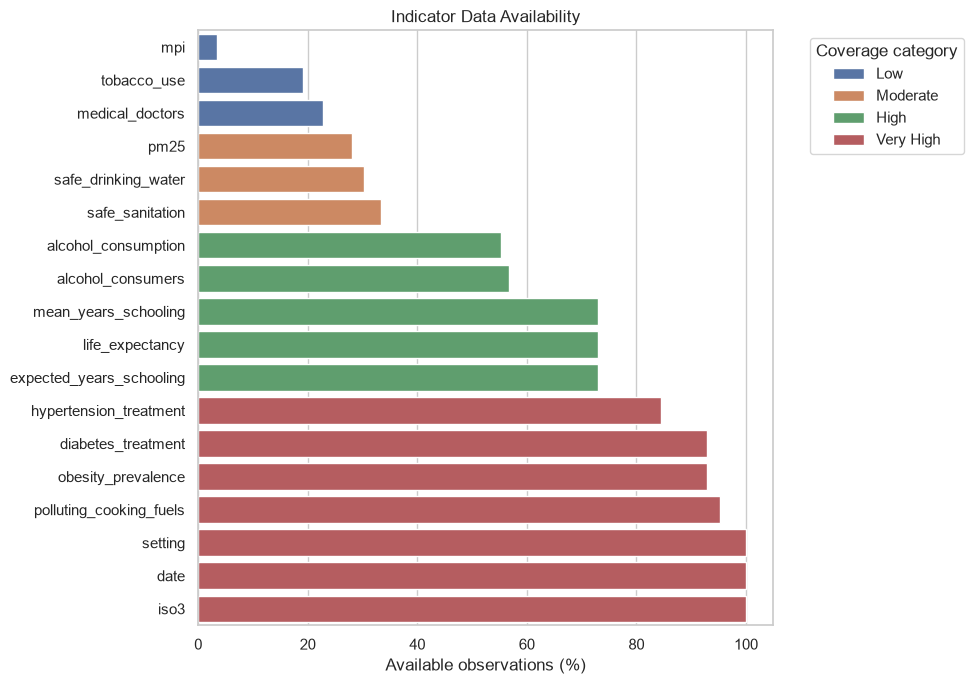

In [68]:
# ===================================================================================
# Plot indicator coverage
# ===================================================================================

plot_indicator_coverage(
    coverage,
    filename="indicator_coverage.png"
)

## Temporal data availability

Overall missingness does not indicate whether indicators are consistently available over time.

Therefore, annual data coverage is examined to identify temporal patterns of availability and determine the period providing the greatest completeness across the selected indicators.

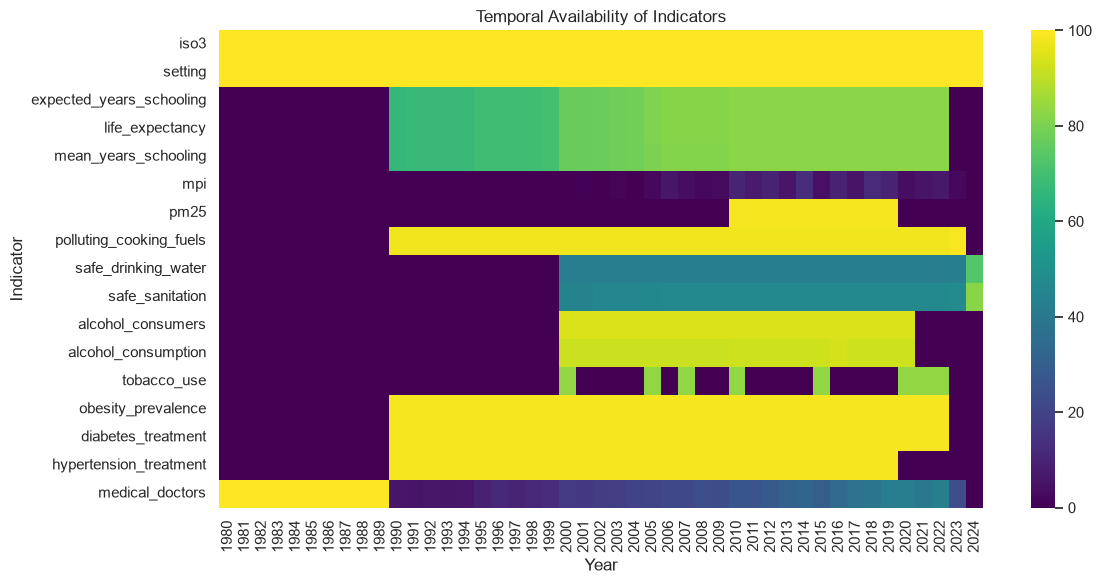

In [69]:
# ===================================================================================
# Plot of data temporal completeness
# ===================================================================================

temporal_coverage_matrix = temporal_coverage(df)


plot_temporal_coverage(
    temporal_coverage_matrix,
    filename="temporal_indicator_coverage.png"
)

## EDA-driven modelling decisions

The exploratory analysis was used to define the analytical dataset that will be used throughout the modelling process.

Variable selection considered three complementary criteria:

- indicator availability;
- temporal consistency;
- epidemiological relevance.

Indicators with very limited coverage were excluded from the primary modelling dataset because they would substantially reduce the effective sample size and require extensive imputation.

The analytical period was restricted to 2000–2022, when the selected indicators showed the most consistent availability across countries.

The resulting modelling dataset contains seven predictors and one target variable (life expectancy).

In [70]:
# =============================================================================
# Defining and creating dataset for model
# =============================================================================

TARGET = "life_expectancy"     # Define target variable

FINAL_PREDICTORS = [           # Define predictor variables
    "obesity_prevalence",
    "diabetes_treatment",
    "polluting_cooking_fuels",
    "hypertension_treatment",
    "mean_years_schooling",
    "expected_years_schooling",
    "alcohol_consumption",
]

# Create modelling dataset
model_df = prepare_model_dataset(
    df=df,
    predictors=FINAL_PREDICTORS,
    target=TARGET,
    start_year=2000,                 # Define analysis period
    end_year=2022
)

# Identifier variables (iso3 and date) are retained for data integrity checks,
# quality control, preprocessing, and traceability.
# They will be removed before model training.

## Modelling dataset overview

After selecting the analytical variables and restricting the study period, the modelling dataset was inspected again.

This second overview confirms the characteristics of the data that will be used during preprocessing and subsequent model development.

In [71]:
# =============================================================================
# Inspect dataset structure
# =============================================================================

print(f"Dataset shape: {model_df.shape}")

print("\nData types:")
display(model_df.dtypes)

print("\nFirst five observations:")
display(model_df.head())

# Calculate missing values
print("\nMissing values:")

missing_summary = (
    pd.DataFrame({
        "Missing values": model_df.isnull().sum(),
        "Percentage (%)": (model_df.isnull().mean() * 100).round(2)
    })
    .sort_values("Percentage (%)", ascending=False)
)

display(missing_summary)

print("\nDescriptive statistics:")

# Calculate Descriptive Analisys
descriptive_stats = model_df.describe().T

descriptive_stats["median"] = (
    model_df
    .select_dtypes(include="number")
    .median()
)
display(descriptive_stats)


Dataset shape: (4554, 10)

Data types:


iso3                            str
date                          int64
obesity_prevalence          float64
diabetes_treatment          float64
polluting_cooking_fuels     float64
hypertension_treatment      float64
mean_years_schooling        float64
expected_years_schooling    float64
alcohol_consumption         float64
life_expectancy             float64
dtype: object


First five observations:


,iso3,date,obesity_prevalence,diabetes_treatment,polluting_cooking_fuels,hypertension_treatment,mean_years_schooling,expected_years_schooling,alcohol_consumption,life_expectancy
10,AFG,2000,4.23,22.85,85.15,27.40,1.21,6.12,0.11,55.41
11,AFG,2001,4.58,22.91,82.70,28.45,1.26,6.43,0.11,55.92
12,AFG,2002,4.95,22.97,80.40,29.55,1.31,6.73,0.29,56.57
13,AFG,2003,5.34,23.03,77.97,30.60,1.36,7.04,0.66,57.46
14,AFG,2004,5.77,23.09,75.75,31.75,1.41,7.95,0.83,58.07



Missing values:


,Missing values,Percentage (%)
mean_years_schooling,853,18.73
expected_years_schooling,848,18.62
life_expectancy,848,18.62
alcohol_consumption,719,15.79
hypertension_treatment,654,14.36
polluting_cooking_fuels,92,2.02
obesity_prevalence,69,1.52
diabetes_treatment,69,1.52
iso3,0,0.00
date,0,0.00



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max,median
date,4554.00,2011.00,6.63,2000.00,2005.00,2011.00,2017.00,2022.00,2011.00
obesity_prevalence,4485.00,19.09,13.03,0.30,9.23,17.82,25.09,71.18,17.82
diabetes_treatment,4485.00,36.94,15.77,7.02,22.53,38.52,49.06,81.27,38.52
polluting_cooking_fuels,4462.00,35.45,37.96,0.00,0.00,17.62,72.59,100.00,17.62
hypertension_treatment,3900.00,35.17,15.06,4.55,22.45,36.35,46.60,73.75,36.35
mean_years_schooling,3701.00,7.65,3.39,0.80,4.96,7.65,10.61,14.78,7.65
expected_years_schooling,3706.00,12.25,3.19,1.64,10.39,12.36,14.75,18.00,12.36
alcohol_consumption,3835.00,11.37,6.97,0.02,6.68,11.07,14.56,71.38,11.07
life_expectancy,3706.00,69.22,8.68,42.13,63.17,70.80,75.76,84.93,70.80


### Interpretation

The final modelling dataset contains 4,554 country-year observations and eight numerical variables, including seven predictors and the target variable.

Compared with the original dataset, the selected variables present substantially higher data completeness while preserving information from education, healthcare, environmental exposure and behavioural risk factors.

Missing values remain in both predictors and the target variable. Their treatment has intentionally been postponed to the preprocessing stage, where observations with missing target values will be removed and missing predictor values will be imputed using an appropriate strategy.

## Distribution of the target variable

The distribution of life expectancy is evaluated to examine its central tendency, variability and degree of asymmetry.

Understanding the distribution of the response variable helps determine whether transformation is required before model development.

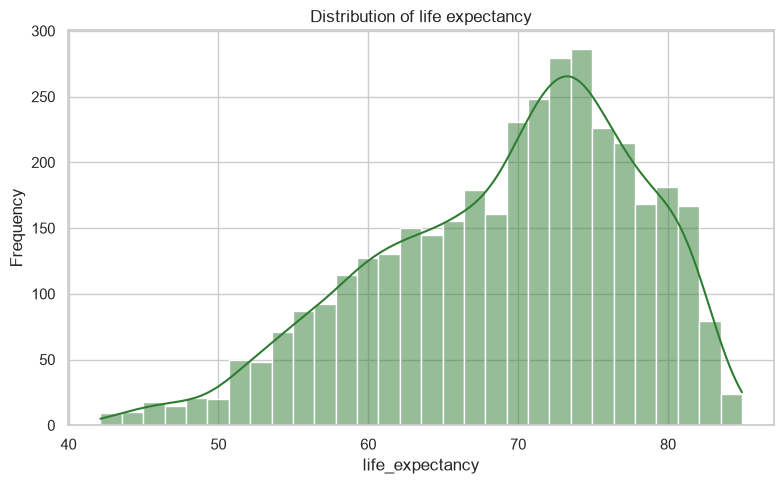

Skewness of life expectancy: -0.57
Median: 70.80 | Mean: 69.22


In [72]:
# =============================================================================
# Distribution of the target variable
# =============================================================================

plot_histogram(
    model_df["life_expectancy"],
    "Distribution of life expectancy",
    "04_life_expectancy_distribution.png"
)


print(
    f"Skewness of life expectancy: {model_df['life_expectancy'].skew():.2f}"
)

print(
    f"Median: {model_df['life_expectancy'].median():.2f} | "
    f"Mean: {model_df['life_expectancy'].mean():.2f}"
)

### Interpretation

Life expectancy presented a moderately left-skewed distribution (skewness = −0.57), with the median (70.80 years) slightly higher than the mean (69.22 years).

The lower tail reflects countries with substantially lower life expectancy, which is expected in a global health dataset and represents meaningful variation rather than data anomalies.

No severe asymmetry or extreme values were observed that would justify transforming the response variable. Therefore, life expectancy will be retained on its original scale throughout model development.

## Correlation analysis

Pearson correlation coefficients are calculated to explore the relationships between the selected predictors and life expectancy.

This analysis provides an initial indication of potentially informative predictors while identifying highly correlated variables that may lead to multicollinearity in linear regression models.

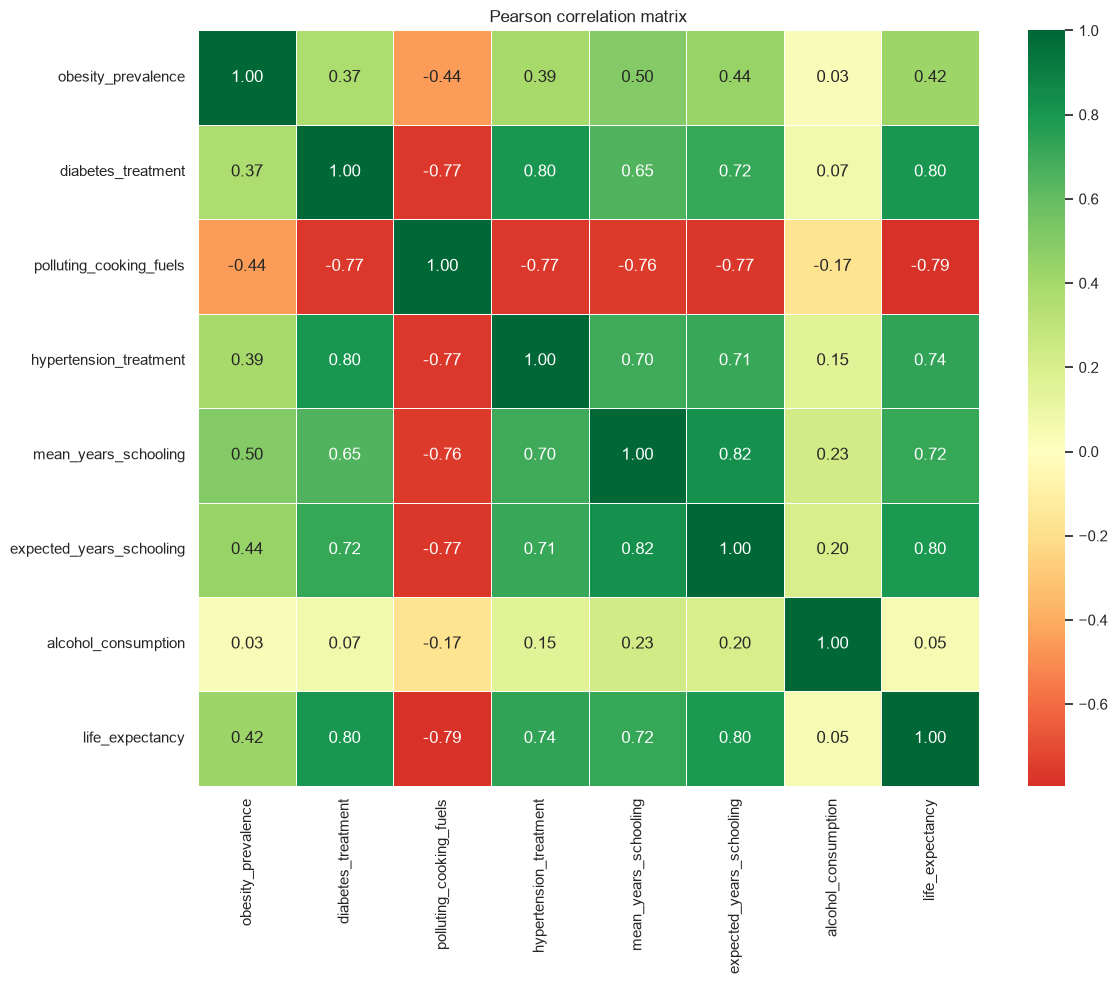

Pairs with |correlation| ≥ 0.70


mean_years_schooling      expected_years_schooling    0.82
diabetes_treatment        life_expectancy             0.80
                          hypertension_treatment      0.80
expected_years_schooling  life_expectancy             0.80
hypertension_treatment    life_expectancy             0.74
mean_years_schooling      life_expectancy             0.72
diabetes_treatment        expected_years_schooling    0.72
hypertension_treatment    expected_years_schooling    0.71
polluting_cooking_fuels   mean_years_schooling       -0.76
diabetes_treatment        polluting_cooking_fuels    -0.77
polluting_cooking_fuels   hypertension_treatment     -0.77
                          expected_years_schooling   -0.77
                          life_expectancy            -0.79
dtype: float64

In [73]:
# =============================================================================
# Correlation matrix among modelling variables
# =============================================================================

corr_cols = FINAL_PREDICTORS + [TARGET]

plot_correlation_heatmap(
    model_df[corr_cols],
    filename="05_correlation_heatmap.png"
)

# Identify highly correlated variable pairs

high_corr = high_correlation_pairs(
    model_df[corr_cols],
    threshold=0.7
)

print("Pairs with |correlation| ≥ 0.70")

display(high_corr)

### Interpretation

Several predictors showed strong associations with life expectancy.

Educational indicators (mean and expected years of schooling), diabetes treatment, hypertension treatment and polluting cooking fuels presented the strongest correlations with the target variable, suggesting that these variables are likely to contribute substantially to predictive performance.

The correlation matrix also revealed strong correlations among some predictors, particularly between the two education indicators and among healthcare-related variables. These relationships suggest potential multicollinearity and will be formally evaluated during model preparation using Variance Inflation Factor (VIF).

## Critical findings (Phase 1)

The exploratory data analysis established the basis for defining the modelling dataset and the subsequent preprocessing strategy.

The main findings are summarized below:

- **The original harmonized dataset contains one observation per country-year**, with no complete duplicate records or duplicated country-year combinations, confirming the integrity of the longitudinal dataset.

- **Indicator availability varied substantially across the WHO indicators.** Variables with less than 50% coverage were excluded because their extensive missingness would considerably reduce the effective sample size and require substantial imputation.

- **Restricting the analysis to the 2000–2022 period** substantially improved data completeness while preserving a large analytical sample of 4,554 country-year observations.

- **The final modelling dataset comprises seven predictors** representing education, healthcare, environmental exposure and behavioural risk factors, together with life expectancy as the response variable.

- **Life expectancy presented only moderate negative skewness** (skewness = −0.57), indicating that no transformation of the target variable is required.

- **Several predictors showed strong correlations with life expectancy**, suggesting that they are promising candidate predictors for regression modelling.

- **Strong correlations were also identified among some predictors**, particularly within education and healthcare indicators, indicating that multicollinearity should be formally assessed before fitting linear regression models.

- **The modelling dataset (`model_df`) was therefore defined but intentionally left unprocessed.** Missing values and preprocessing operations will be addressed in Phase 2 before model training.

# Phase 2 - Data Processing and Cleaning

This phase applies the necessary steps to prepare the dataset for predictive modelling.

The analyses performed in Phase 1 demonstrated that:

- no complete duplicates or repeated country-year observations were identified;
- missing values are present due to the integration of multiple international indicators;

The data processing workflow will follow three main steps:

1. Confirmation of the absence of duplicate observations;
2. Treatment of missing values;
3. Assessment and management of outliers in predictor variables.

Processing decisions will be guided by the main objective of the model: predicting life expectancy (`life_expectancy`).

In [74]:
# =============================================================================
# Assessment of duplicates
# =============================================================================

# Complete duplicates

n_duplicates = model_df.duplicated().sum()

print(f"Complete duplicate rows: {n_duplicates}")

# Duplicate country-year observations

n_country_year = model_df.duplicated(
    subset=["iso3", "date"]
).sum()

print(f"Duplicate country-year observations: {n_country_year}")

if n_country_year > 0:
    display(
        model_df.loc[
            model_df.duplicated(
                subset=["iso3", "date"],
                keep=False
            )
        ].sort_values(["iso3", "date"])
    )

Complete duplicate rows: 0
Duplicate country-year observations: 0


In [75]:
# =============================================================================
# Assessment of missing values
# =============================================================================

# Missing values before treatment

print("Missing values and skewness by variable:")

# Missing values summary
missing_summary = (
    pd.DataFrame({
        "Missing values": model_df.isna().sum(),
        "Missing (%)": (
            model_df.isna().mean() * 100
        ).round(2)
    })
)

# Calculate skewness only for numeric variables
predictor_skewness = (
    model_df
    .select_dtypes(include="number")
    .skew()
    .rename("Skewness")
)

# Combine information
data_quality_summary = (
    missing_summary
    .join(predictor_skewness)
    .sort_values(
        "Missing (%)",
        ascending=False
    )
)

display(data_quality_summary)

Missing values and skewness by variable:


,Missing values,Missing (%),Skewness
mean_years_schooling,853,18.73,-0.06
expected_years_schooling,848,18.62,-0.37
life_expectancy,848,18.62,-0.57
alcohol_consumption,719,15.79,1.81
hypertension_treatment,654,14.36,0.02
polluting_cooking_fuels,92,2.02,0.54
obesity_prevalence,69,1.52,1.27
diabetes_treatment,69,1.52,0.09
iso3,0,0.00,NaN
date,0,0.00,0.00


In [76]:
# =============================================================================
# Missing value treatment
# =============================================================================

# Remove observations without target values
model_df = remove_missing_target(
    model_df,
    TARGET
)

# Median imputation for predictor variables
model_df = median_imputation(
    model_df,
    FINAL_PREDICTORS
)

# Verify remaining missing values
print("Remaining missing values:")
display(
    model_df.isna().sum()
)

Remaining missing values:


iso3                        0
date                        0
obesity_prevalence          0
diabetes_treatment          0
polluting_cooking_fuels     0
hypertension_treatment      0
mean_years_schooling        0
expected_years_schooling    0
alcohol_consumption         0
life_expectancy             0
dtype: int64

### Missing value treatment

Observations without the target variable (`life_expectancy`) were removed because supervised learning requires known outcome values.

Missing values among predictor variables were replaced using median imputation.

The median was selected because the variables present heterogeneous distributions and potential extreme observations. Compared with mean imputation, the median is less affected by skewed distributions and outliers.

,Variable,Lower limit,Upper limit,Outliers
0,obesity_prevalence,-13.82,44.69,72
1,diabetes_treatment,-19.99,89.34,0
2,polluting_cooking_fuels,-116.18,193.62,0
3,hypertension_treatment,-10.08,77.47,0
4,mean_years_schooling,-3.50,19.07,0
5,expected_years_schooling,3.86,21.28,28
6,alcohol_consumption,-1.86,24.05,173


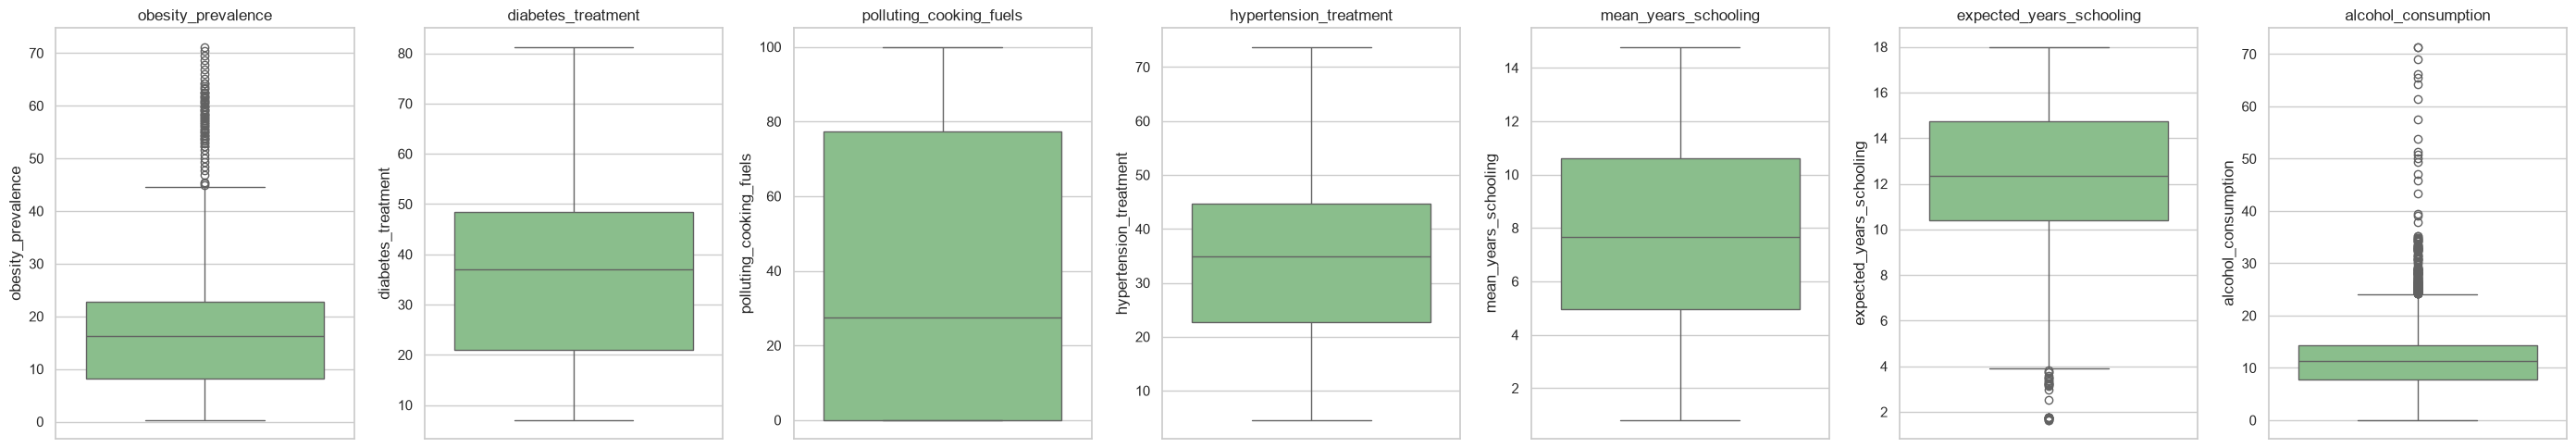

In [77]:
# =============================================================================
# Outliers assessment and treatment
# =============================================================================

# IQR method for outliers detection
display(
    summarize_outliers(
        model_df,
        FINAL_PREDICTORS
    )
)

# Boxplots for predictor variables
plot_boxplots(
    model_df,
    FINAL_PREDICTORS,
    filename="06_predictor_boxplots.png"
)

### Outlier management

Potential outliers were identified using the Interquartile Range (IQR) method.

Extreme observations were detected mainly in obesity prevalence, expected years of schooling, and alcohol consumption.

However, these observations were maintained because they represent plausible epidemiological differences between countries rather than data collection errors.

Removing these observations could reduce the variability of the dataset and limit the model's ability to capture global health inequalities.

Alternative strategies, including logarithmic transformations and sensitivity analyses excluding extreme observations, will be evaluated during model development.

In [78]:
# =============================================================================
# Processed dataset verification
# =============================================================================

# Verify cleaned dataset
print("=" * 60)
print("PHASE 2 - CLEAN DATASET SUMMARY")
print("=" * 60)

print(f"Dataset shape: {model_df.shape}")

print("\nRemaining missing values:")
display(model_df.isna().sum())

print("\nData types:")
display(model_df.dtypes)

print("\nFirst five observations:")
display(model_df.head())


# Save cleaned dataset
save_processed_dataset(
    model_df,
    "model_df_clean.csv"
)

PHASE 2 - CLEAN DATASET SUMMARY
Dataset shape: (3706, 10)

Remaining missing values:


iso3                        0
date                        0
obesity_prevalence          0
diabetes_treatment          0
polluting_cooking_fuels     0
hypertension_treatment      0
mean_years_schooling        0
expected_years_schooling    0
alcohol_consumption         0
life_expectancy             0
dtype: int64


Data types:


iso3                            str
date                          int64
obesity_prevalence          float64
diabetes_treatment          float64
polluting_cooking_fuels     float64
hypertension_treatment      float64
mean_years_schooling        float64
expected_years_schooling    float64
alcohol_consumption         float64
life_expectancy             float64
dtype: object


First five observations:


,iso3,date,obesity_prevalence,diabetes_treatment,polluting_cooking_fuels,hypertension_treatment,mean_years_schooling,expected_years_schooling,alcohol_consumption,life_expectancy
0,AFG,2000,4.23,22.85,85.15,27.40,1.21,6.12,0.11,55.41
1,AFG,2001,4.58,22.91,82.70,28.45,1.26,6.43,0.11,55.92
2,AFG,2002,4.95,22.97,80.40,29.55,1.31,6.73,0.29,56.57
3,AFG,2003,5.34,23.03,77.97,30.60,1.36,7.04,0.66,57.46
4,AFG,2004,5.77,23.09,75.75,31.75,1.41,7.95,0.83,58.07


Processed dataset saved: /Users/anandastaats/who-life-expectancy_prediction/data/processed/model_df_clean.csv


# Phase 3 – Feature Engineering

The correlation analysis from EDA identified strong correlations among some predictors, suggesting that they capture similar underlying information.

In particular:

- `mean_years_schooling` and `expected_years_schooling` (r = 0.82);
- `diabetes_treatment` and `hypertension_treatment` (r = 0.80).

Rather than immediately removing correlated variables, this phase focuses on creating new informative features derived from existing variables. These engineered variables aim to summarize related information while preserving the original indicators for later comparison.

Potential multicollinearity will be formally assessed during the modelling stage using the VIF, allowing an evidence-based decision regarding variable selection.

In [79]:
# =============================================================================
# Create engineered features
# =============================================================================

df_engineered = add_features(model_df)

display(
    df_engineered[
        [
            "education_index",
            "healthcare_index"
        ]
    ].head()
)

,education_index,healthcare_index
0,3.67,25.13
1,3.84,25.68
2,4.02,26.26
3,4.20,26.82
4,4.68,27.42


In [80]:
# =============================================================================
# Save engineered dataset
# =============================================================================

save_processed_dataset(
    df_engineered,
    "model_df_feature_engineering.csv"
)

Processed dataset saved: /Users/anandastaats/who-life-expectancy_prediction/data/processed/model_df_feature_engineering.csv


In [81]:
# =============================================================================
# Keep a copy of modelling dataset containing engineered features
# =============================================================================

model_df_engineered = model_df.copy()

# Phase 4 - Model Preparation

This phase prepares the dataset for predictive modelling.

Following data cleaning (Phase 2) and the creation of derived features (Phase 3), the dataset undergoes the necessary preprocessing steps for Machine Learning model development:

- definition of the predictor variables and target variable;
- splitting the data into training and testing sets;
- assessment of multicollinearity among predictor variables using the VIF;
- standardization of numerical variables for scale-sensitive algorithms.

These steps ensure that model training is performed using only information available during the learning process, thereby preventing data leakage.

In [82]:
# =============================================================================
# Select baseline model predictors
# =============================================================================

FINAL_FEATURES = [

    "obesity_prevalence",

    "diabetes_treatment",

    "polluting_cooking_fuels",

    "hypertension_treatment",

    "mean_years_schooling",

    "expected_years_schooling",

    "alcohol_consumption",

]

# =============================================================================
# Definition of the predictor and target variables for the baseline model
# =============================================================================

model_df_baseline = select_final_columns(
    model_df,
    FINAL_PREDICTORS,
    TARGET
)

print(model_df_baseline.shape)
display(model_df_baseline.head())

(3706, 8)


,obesity_prevalence,diabetes_treatment,polluting_cooking_fuels,hypertension_treatment,mean_years_schooling,expected_years_schooling,alcohol_consumption,life_expectancy
0,4.23,22.85,85.15,27.40,1.21,6.12,0.11,55.41
1,4.58,22.91,82.70,28.45,1.26,6.43,0.11,55.92
2,4.95,22.97,80.40,29.55,1.31,6.73,0.29,56.57
3,5.34,23.03,77.97,30.60,1.36,7.04,0.66,57.46
4,5.77,23.09,75.75,31.75,1.41,7.95,0.83,58.07


In [83]:
# =============================================================================
# Select engineered predictors
# =============================================================================

FINAL_PREDICTORS_ENGINEERED = [

    "obesity_prevalence",

    "polluting_cooking_fuels",

    "alcohol_consumption",

    "education_index",

    "healthcare_index",

]

# =============================================================================
# Create engineered modelling dataset
# =============================================================================

model_df_engineered = select_final_columns(

    df_engineered,

    FINAL_PREDICTORS_ENGINEERED,

    TARGET,

)

model_df_engineered.head()

,obesity_prevalence,polluting_cooking_fuels,alcohol_consumption,education_index,healthcare_index,life_expectancy
0,4.23,85.15,0.11,3.67,25.13,55.41
1,4.58,82.70,0.11,3.84,25.68,55.92
2,4.95,80.40,0.29,4.02,26.26,56.57
3,5.34,77.97,0.66,4.20,26.82,57.46
4,5.77,75.75,0.83,4.68,27.42,58.07


## Train-Test Split

The dataset is divided into training and testing sets before model training.

The training set is used to fit the machine learning algorithms, while the testing set remains completely independent and is used exclusively for evaluating the final model performance.

An 80/20 train-test split was adopted, with `random_state=42` to ensure reproducibility.

In [84]:
# =============================================================================
# Split predictors and target from baseline dataset model 
# =============================================================================

from sklearn.model_selection import train_test_split

X = model_df_baseline.drop(columns=[TARGET])
y = model_df_baseline[TARGET]

# =============================================================================
# Train-test split - baseline dataset model
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Testing set : {X_test.shape}")

Training set: (2964, 7)
Testing set : (742, 7)


In [85]:
# =============================================================================
# Split predictors and target from engineered modelling dataset
# =============================================================================

X_eng = model_df_engineered.drop(columns=[TARGET])

y_eng = model_df_engineered[TARGET]

# =============================================================================
# Train-test split - engineered modelling dataset
# =============================================================================

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(

    X_eng,

    y_eng,

    test_size=0.20,

    random_state=42,

)
print(f"Training engineered set: {X_train_eng.shape}")
print(f"Testing engineered set : {X_test_eng.shape}")

Training engineered set: (2964, 5)
Testing engineered set : (742, 5)


## Assessment of Multicollinearity

The EAD identified relatively high correlations between some predictor variables, particularly:

- `mean_years_schooling` × `expected_years_schooling` (r = 0.82)
- `diabetes_treatment` × `hypertension_treatment` (r = 0.80)

However, Pearson correlation assesses only pairwise relationships between variables.

To determine whether multicollinearity could adversely affect the estimation of the linear regression coefficients, the VIF was calculated. Unlike Pearson correlation, VIF evaluates the combined relationship among all predictor variables included in the model.

VIF values below 5 generally indicate low multicollinearity, whereas values above 10 suggest substantial redundancy among predictors.

In [86]:
# =============================================================================
# Calculation of Variance Inflation Factor
# =============================================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_vif = sm.add_constant(X_train)

vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif.values,
            i
        )
        for i in range(X_vif.shape[1])
    ]
})

display(vif.sort_values("VIF", ascending=False))

,Variable,VIF
0,const,71.03
6,expected_years_schooling,3.97
3,polluting_cooking_fuels,3.83
5,mean_years_schooling,3.65
2,diabetes_treatment,3.27
4,hypertension_treatment,2.54
1,obesity_prevalence,1.45
7,alcohol_consumption,1.09


The VIF values remained below the critical threshold adopted in this study, indicating the absence of severe multicollinearity among the predictor variables.

Although some predictors exhibited relatively high Pearson correlations during the exploratory data analysis, they did not introduce sufficient redundancy to compromise the stability of the linear regression coefficients.

Therefore, all predictor variables were retained for the model training stage.

## Feature Scaling

The predictor variables are measured on substantially different scales.

Although tree-based algorithms do not require feature scaling, models such as Linear Regression, Ridge Regression, and Lasso Regression can be influenced by differences in feature magnitude.

Therefore, the predictor variables were standardized using `StandardScaler`, which was fitted exclusively on the training set and subsequently applied to the testing set. This approach prevents data leakage by ensuring that no information from the testing data is used during model training.

In [87]:
# =============================================================================
# Standarization predictors - Baseline dataset
# =============================================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [88]:
# =============================================================================
# Standardize predictors - Engineered modelling dataset
# =============================================================================

scaler_eng = StandardScaler()

X_train_eng_scaled = scaler_eng.fit_transform(
    X_train_eng
)

X_test_eng_scaled = scaler_eng.transform(
    X_test_eng
)

# Phase 5 – Model Development and Evaluation

This phase develops, evaluates, and compares predictive models for estimating life expectancy using the WHO HIDR.

The evaluation is organized into successive stages, beginning with a simple and interpretable baseline model and progressing to a more flexible machine learning algorithm.

The workflow includes:

1. Training a baseline Multiple Linear Regression model using the original predictor variables.
2. Evaluating model performance using regression metrics and graphical diagnostics.
3. Comparing the baseline model with a K-Nearest Neighbors (KNN) regression model.
4. Assessing model robustness through 5-fold cross-validation.
5. Evaluating whether engineered features improve predictive performance.
6. Selecting the final model for retraining and versioning in Phase 6.

This progressive evaluation provides a transparent comparison between interpretability, predictive accuracy, and model robustness.

## 5.1 Baseline Model: Multiple Linear Regression

Multiple Linear Regression was selected as the baseline model because it is one of the most widely used regression algorithms and provides a highly interpretable benchmark for continuous outcome prediction.

The model assumes a linear relationship between the predictor variables and life expectancy, allowing the contribution of each predictor to be estimated directly through regression coefficients.

The baseline model was trained using the standardized predictor variables created during the preprocessing stage.

After training, predictions are generated for both the training and testing datasets to evaluate predictive performance and assess the model's ability to generalize to unseen observations.

In [89]:
# =============================================================================
# Import Linear Regression
# =============================================================================

from sklearn.linear_model import LinearRegression

# =============================================================================
# Initialize the baseline model
# =============================================================================

baseline_model = LinearRegression()

# =============================================================================
# Train the baseline model
# =============================================================================

baseline_model.fit(X_train_scaled, y_train,)

# =============================================================================
# Generate predictions
# =============================================================================

y_train_pred = baseline_model.predict(X_train_scaled,)

y_test_pred = baseline_model.predict(X_test_scaled,)

# =============================================================================
# Preview predictions
# =============================================================================

pd.DataFrame(
    {
        "Observed": y_test.values,
        "Predicted": y_test_pred,
    }
).head(10)

,Observed,Predicted
0,48.12,63.99
1,77.75,77.38
2,75.32,78.68
3,78.67,78.14
4,77.02,80.16
5,68.60,74.35
6,69.66,68.58
7,63.78,70.94
8,70.86,73.47
9,69.51,61.93


### Interpretation

The baseline Multiple Linear Regression model was successfully fitted using the standardized training dataset.

Predictions were generated for both the training and testing sets. The training predictions will be used to assess how well the model learned the relationships present in the training data, while the testing predictions provide an unbiased estimate of the model's predictive performance on previously unseen observations.

The preview above provides a first qualitative inspection of the agreement between observed and predicted life expectancy values before performing a more comprehensive quantitative evaluation.

## 5.2 Diagnostic Evaluation of the Baseline Model

Numerical performance metrics alone do not fully describe model behaviour.

Graphical diagnostic analyses provide additional insight into prediction quality and help identify systematic errors that may not be evident from summary statistics.

Two complementary diagnostic plots are evaluated:

- Observed versus predicted values;
- Residual distribution.

Together, these visualizations help assess predictive accuracy, model bias, and the adequacy of the linear regression assumptions.

### Observed versus Predicted Values

The observed versus predicted plot compares the actual life expectancy values with the predictions generated by the model.

Predictions located close to the diagonal reference line indicate good agreement between observed and predicted values. Larger deviations from the line correspond to greater prediction errors.

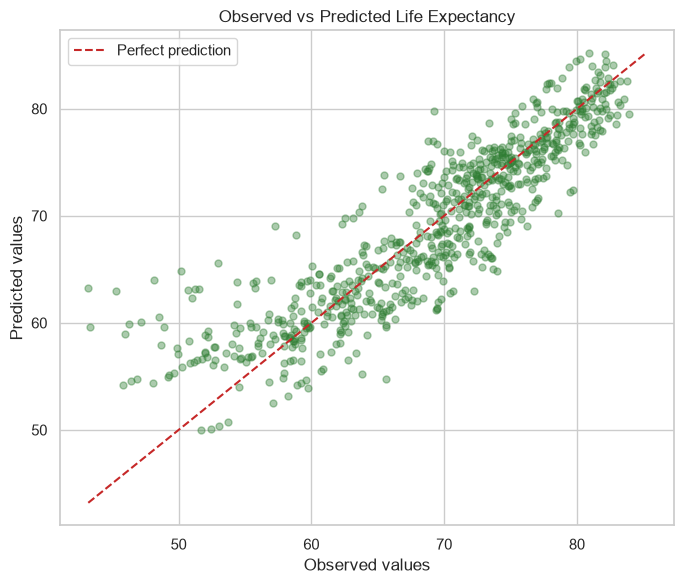

In [90]:
# =============================================================================
# Observed versus predicted values
# =============================================================================

plot_observed_vs_predicted(
    y_test,
    y_test_pred,
    title="Observed vs Predicted Life Expectancy",
    filename="06_observed_vs_predicted.png",
)

### Interpretation

The observed versus predicted plot demonstrates that most predictions are concentrated around the diagonal reference line.

This pattern indicates good agreement between observed and predicted life expectancy values, suggesting that the baseline linear regression model captures a substantial proportion of the variability present in the data.

Although some observations deviate from the reference line, no obvious systematic prediction bias is visually apparent.

### Residual Analysis

Residuals represent the difference between the observed and predicted life expectancy values.

Evaluating residuals helps determine whether prediction errors are randomly distributed around zero, as expected under the assumptions of linear regression.

Systematic trends or increasing variability across the prediction range may indicate model misspecification or violations of regression assumptions.

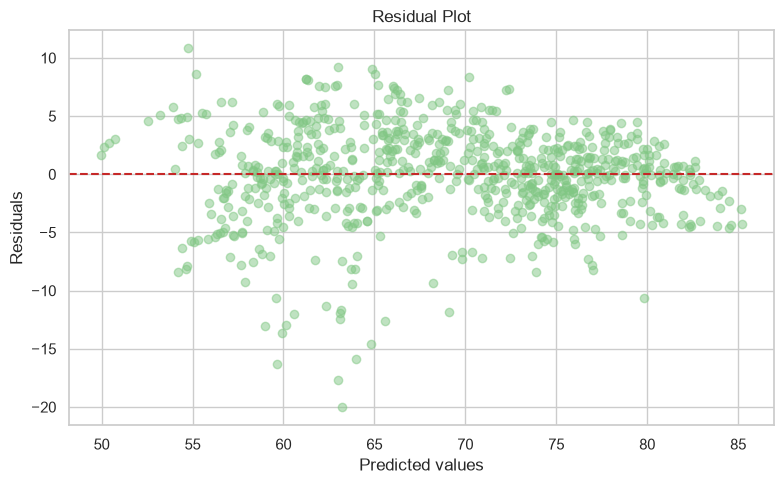

Mean residual: -0.06
Residual standard deviation: 4.00


In [91]:
# =============================================================================
# Residual analysis
# =============================================================================

residuals = plot_residuals(
    y_test,
    y_test_pred,
    title="Residual Plot",
    filename="07_residuals.png",
)

print(f"Mean residual: {residuals.mean():.2f}")
print(f"Residual standard deviation: {residuals.std():.2f}")

### Interpretation

The residuals are centered close to zero, indicating that the model does not systematically overestimate or underestimate life expectancy.

The relatively small residual standard deviation suggests that most prediction errors are modest in magnitude.

Furthermore, the absence of clear systematic patterns in the residual plot supports the assumption that the linear regression model provides an adequate approximation of the relationship between the selected predictors and life expectancy.

These graphical diagnostics complement the quantitative evaluation presented in the next section.

## 5.3 Quantitative Performance Evaluation of the Baseline Model

After visually inspecting the model predictions and residuals, the baseline model is evaluated using standard regression metrics.

Four complementary performance measures are calculated:

- **Mean Absolute Error (MAE)** measures the average prediction error.
- **Mean Squared Error (MSE)** penalizes larger prediction errors.
- **Root Mean Squared Error (RMSE)** expresses prediction error in the original unit (years).
- **Coefficient of Determination (R²)** quantifies the proportion of variability in life expectancy explained by the model.

Performance is calculated separately for the training and testing datasets. Comparing both sets provides an indication of the model's generalization ability and helps identify potential overfitting.

In [92]:
# =============================================================================
# Import evaluation metrics
# =============================================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import numpy as np


# =============================================================================
# Calculate performance metrics
# =============================================================================

# Training performance
metrics_train = {

    "MAE": mean_absolute_error(y_train, y_train_pred,),

    "MSE": mean_squared_error(y_train, y_train_pred,),

    "RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred,)),

    "R²": r2_score(y_train, y_train_pred,),
}


# Testing performance
metrics_test = {

    "MAE": mean_absolute_error(y_test, y_test_pred,),

    "MSE": mean_squared_error(y_test, y_test_pred,),

    "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred,)),

    "R²": r2_score(y_test, y_test_pred,),
}


# =============================================================================
# Compare training and testing performance
# =============================================================================

baseline_performance = pd.DataFrame({

    "Training": metrics_train,
    "Testing": metrics_test,

})

display(
    baseline_performance.round(4)
)

,Training,Testing
MAE,2.96,2.96
MSE,16.76,15.95
RMSE,4.09,3.99
R²,0.78,0.79


### Interpretation

The baseline Multiple Linear Regression model achieved very similar performance on the training and testing datasets across all evaluation metrics.

The close agreement between the two sets indicates that the model generalizes well to previously unseen observations and shows no evidence of substantial overfitting.

The coefficient of determination (R²) indicates that the model explains a large proportion of the variability in life expectancy, while the relatively low MAE and RMSE values demonstrate good predictive accuracy.

Overall, these results establish Multiple Linear Regression as a strong and interpretable baseline for comparison with more flexible machine learning algorithms.

## 5.4 Comparison with an Alternative Regression Algorithm

Although Multiple Linear Regression provides excellent interpretability, it assumes that the relationship between the predictors and the response variable is approximately linear.

Real-world public health indicators frequently exhibit non-linear interactions.

To investigate whether a more flexible machine learning algorithm can better capture these relationships, the baseline model is compared with a **K-Nearest Neighbors (KNN) Regressor**.

Unlike Linear Regression, KNN is a distance-based algorithm that predicts new observations according to the values of their nearest neighbors.

Because distance calculations are directly influenced by variable scales, predictor standardization is required before training the KNN model.

Both algorithms are evaluated using exactly the same training and testing datasets to ensure a fair comparison.

In [93]:
# =============================================================================
# Import KNN Regressor
# =============================================================================

from sklearn.neighbors import KNeighborsRegressor

# =============================================================================
# Train the KNN model
# =============================================================================

knn_model = KNeighborsRegressor()

knn_model.fit(X_train_scaled, y_train,)

# =============================================================================
# Generate KNN predictions
# =============================================================================

knn_train_pred = knn_model.predict(X_train_scaled,)

knn_test_pred = knn_model.predict(X_test_scaled,)

# =============================================================================
# Calculate KNN performance
# =============================================================================

# Training performance
knn_metrics_train = {

    "MAE": mean_absolute_error(y_train,knn_train_pred,),
    "MSE": mean_squared_error(y_train, knn_train_pred),
    "RMSE": np.sqrt(mean_squared_error(y_train, knn_train_pred,)),
    "R²": r2_score(y_train, knn_train_pred,),
}

# Testing performance
knn_metrics_test = {
    "MAE": mean_absolute_error(y_test,knn_test_pred,),
    "MSE": mean_squared_error(y_test, knn_test_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, knn_test_pred,)),
    "R²": r2_score(y_test, knn_test_pred,)
}

# =============================================================================
# Compare training and testing performance for KNN model
# =============================================================================

knn_baseline_performance = pd.DataFrame({
    "KNN Training": knn_metrics_train,
    "KNN Testing": knn_metrics_test,
})

display(knn_baseline_performance.round(4))


,KNN Training,KNN Testing
MAE,0.58,0.83
MSE,1.26,2.61
RMSE,1.12,1.62
R²,0.98,0.97


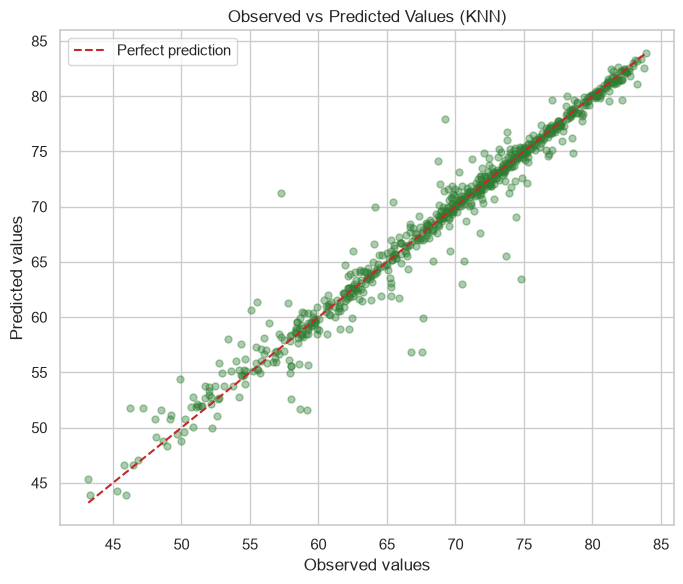

In [94]:
# =============================================================================
# KNN observed vs predictive analysis
# =============================================================================

plot_observed_vs_predicted(
    y_test,
    knn_test_pred,
    title="Observed vs Predicted Values (KNN)",
    filename="08_knn_observed_vs_predicted.png",
)

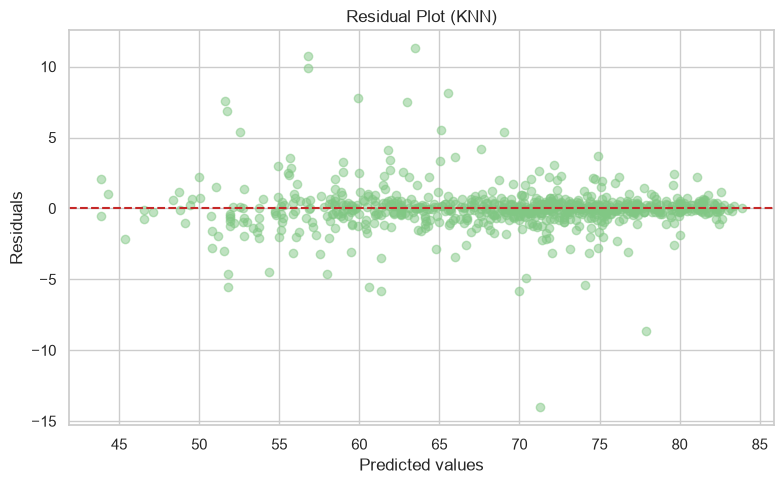

Mean residual: -0.00
Residual standard deviation: 1.62


In [95]:
# =============================================================================
# KNN residual analysis
# =============================================================================

residuals_knn = plot_residuals(
    y_test,
    knn_test_pred,
    title="Residual Plot (KNN)",
    filename="09_knn_residuals.png",
)

print(f"Mean residual: {residuals_knn.mean():.2f}")
print(f"Residual standard deviation: {residuals_knn.std():.2f}")


### Interpretation

The K-Nearest Neighbors (KNN) regression model achieved excellent predictive performance on both the training and testing datasets.

The model obtained a training RMSE of **1.12 years** and a testing RMSE of **1.62 years**, indicating that prediction errors remained low when applied to previously unseen observations. Similarly, the coefficient of determination (R²) decreased only slightly from **0.98** on the training set to **0.97** on the testing set.

The small differences between training and testing performance suggest that the model generalizes well and shows no evidence of substantial overfitting. The consistently low MAE values further indicate that the average prediction error is less than one year on the testing dataset.

Regarding the KNN Diagnostic Plots, the observed versus predicted plot demonstrates a strong agreement between the predicted and observed life expectancy values, with most observations positioned close to the diagonal reference line. This indicates that the KNN regression model is able to accurately capture the relationship between the selected predictors and life expectancy.

The residual plot shows that prediction errors are randomly distributed around zero, with no clear systematic pattern or evidence of substantial bias. The mean residual was approximately zero (-0.00 years), indicating that the model does not consistently overestimate or underestimate life expectancy.

The residual standard deviation was 1.62 years, which is consistent with the RMSE obtained during model evaluation. This low residual variability confirms the strong predictive performance of the KNN model and explains the improvement observed compared with the Linear Regression baseline.

In [96]:
# =============================================================================
# Compare regression models
# =============================================================================


model_comparison = pd.DataFrame(
    [
        {
            "Model": "Multiple Linear Regression",
            **metrics_test,
        },
        {
            "Model": "K-Nearest Neighbors",
            **knn_metrics_test,
        },
    ]
)

display(model_comparison.round(4))

,Model,MAE,MSE,RMSE,R²
0,Multiple Linear Regression,2.96,15.95,3.99,0.79
1,K-Nearest Neighbors,0.83,2.61,1.62,0.97


### Interpretation

The comparison demonstrates the relative strengths of the two regression algorithms.

Multiple Linear Regression provides an interpretable baseline capable of explaining the contribution of each predictor to life expectancy.

The K-Nearest Neighbors model, however, is able to capture more complex and potentially non-linear relationships between the selected predictors and the response variable.

Compared with the baseline Multiple Linear Regression model, KNN substantially reduced the prediction error while explaining a greater proportion of the variability in life expectancy. These results suggest that the relationships between the selected health, socioeconomic, environmental, and behavioural indicators and life expectancy are not fully linear, and that the KNN algorithm is able to capture additional non-linear patterns present in the data.

Because the dataset contains repeated observations from the same countries over multiple years, additional validation of the train-test splitting strategy is required to confirm that the observed performance reflects true generalization rather than similarity between country-year observations.

## 5.5 Robustness Assessment Using 5-Fold Cross-Validation

Although the train-test split provides an estimate of predictive performance on unseen observations, the results may vary depending on the random partition of the dataset.

To evaluate the stability and robustness of the candidate models, a **5-fold cross-validation** procedure was performed.

During cross-validation, the complete modelling dataset is divided into five equally sized subsets (folds). In each iteration, four folds are used for training while the remaining fold is used for validation. This process is repeated until every observation has served once as validation data.

The average performance across the five folds provides a more reliable estimate of model generalization than a single train-test split.

Both Multiple Linear Regression and K-Nearest Neighbors were evaluated using the same cross-validation strategy.

In [97]:
# =============================================================================
# Import cross-validation tools
# =============================================================================

from sklearn.model_selection import (
    KFold,
    cross_val_score,
)

from sklearn.pipeline import Pipeline

# =============================================================================
# Define cross-validation strategy
# =============================================================================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

# =============================================================================
# Define modelling pipelines
# =============================================================================

linear_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)

knn_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor()),
    ]
)

# =============================================================================
# Evaluate models using cross-validation
# =============================================================================

cv_results = []

for name, model in {

    "Multiple Linear Regression": linear_pipeline,
    "K-Nearest Neighbors": knn_pipeline,

}.items():

    mae = -cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="neg_mean_absolute_error",
    )

    rmse = -cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="neg_root_mean_squared_error",
    )

    r2 = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="r2",
    )

    cv_results.append(
        {

            "Model": name,

            "MAE":

            f"{mae.mean():.2f} ± {mae.std():.2f}",

            "RMSE":

            f"{rmse.mean():.2f} ± {rmse.std():.2f}",

            "R²":

            f"{r2.mean():.2f} ± {r2.std():.2f}",

        }
    )

cv_summary = pd.DataFrame(cv_results)

display(cv_summary)

,Model,MAE,RMSE,R²
0,Multiple Linear Regression,2.97 ± 0.05,4.09 ± 0.07,0.78 ± 0.01
1,K-Nearest Neighbors,0.84 ± 0.03,1.53 ± 0.08,0.97 ± 0.00


### Interpretation

The cross-validation results confirmed the performance observed during the train-test evaluation.

Both models produced consistent results across the five folds, indicating stable predictive performance and limited sensitivity to the specific data partition.

However, the K-Nearest Neighbors model consistently achieved lower prediction errors and higher coefficients of determination than Multiple Linear Regression.

The low variability observed across folds further suggests that the superior performance of KNN is robust rather than being an artifact of a particular train-test split.

Based on these results, KNN was selected as the best-performing algorithm for subsequent experiments.

## 5.6 Evaluation of Engineered Features

The final experiment investigated whether domain-informed feature engineering could improve predictive performance.

During Phase 3, two composite variables were created:

- **Education Index**, combining mean years of schooling and expected years of schooling;
- **Healthcare Index**, combining diabetes treatment coverage and hypertension treatment coverage.

These engineered variables replace the original predictors used in their construction, reducing redundancy while preserving the underlying information.

The K-Nearest Neighbors model was retrained using the engineered feature set and evaluated under the same modelling strategy used for the original predictors.

In [98]:
# =============================================================================
# Train KNN using engineered predictors
# =============================================================================

knn_engineered = KNeighborsRegressor()

knn_engineered.fit(X_train_eng_scaled, y_train_eng,)

pred_test_knn_eng = knn_engineered.predict(X_test_eng_scaled)

# =============================================================================
# Evaluate engineered model
# =============================================================================

engineered_metrics = {

    "MAE": mean_absolute_error(y_test_eng, pred_test_knn_eng,),

    "MSE": mean_squared_error(y_test_eng, pred_test_knn_eng),
    
    "RMSE": np.sqrt(mean_squared_error(y_test_eng,pred_test_knn_eng,)),

    "R²":r2_score(y_test_eng,pred_test_knn_eng,),

}

pd.DataFrame(

    [engineered_metrics],

    index=["KNN + Engineered Features"],

).round(4)

# =============================================================================
# Compare feature representations
# =============================================================================

feature_comparison = pd.DataFrame(

    [

        {

            "Model":

            "KNN (Original Predictors)",

            **knn_metrics_test,

        },

        {

            "Model":

            "KNN (Engineered Features)",

            **engineered_metrics,

        },

    ]

)

display(feature_comparison.round(4))

,Model,MAE,MSE,RMSE,R²
0,KNN (Original Predictors),0.83,2.61,1.62,0.97
1,KNN (Engineered Features),0.91,2.64,1.62,0.97


### Interpretation

The comparison between the original predictor set and the engineered feature representation showed very similar predictive performance.

The K-Nearest Neighbors model trained with the original predictors achieved a slightly lower Mean Absolute Error (MAE = 0.83 years) than the model using engineered features (MAE = 0.91 years). Both models produced virtually identical Root Mean Squared Error (RMSE = 1.62 years) and explained approximately 97% of the variability in life expectancy (R² = 0.97).

These results indicate that replacing the original education- and healthcare-related variables with composite indices did not improve predictive performance. Although the engineered features provide a more compact and potentially more interpretable representation of related domains, the original predictors retained slightly greater predictive information for the KNN model.

Consequently, the K-Nearest Neighbors model trained using the original predictor variables was retained as the preferred modelling approach for the remainder of the analysis.

# Phase 6 – Final Model Evaluation, Interpretation and Versioning

The previous phase compared multiple regression algorithms and alternative feature representations.

Based on predictive accuracy, robustness across cross-validation, and generalization performance, the best-performing model was selected.

This final phase retrains the selected model using the complete modelling dataset, stores the fitted model for future use, and summarizes the overall modelling workflow.

## 6.1 Final Model Selection

Three modelling strategies were evaluated throughout this project:

- Multiple Linear Regression using the original predictor variables;
- K-Nearest Neighbors (KNN) using the original predictor variables;
- KNN using engineered features.

Model selection considered multiple criteria, including prediction accuracy, model robustness during cross-validation, and consistency between training and testing performance.

The KNN model trained using the original predictor variables achieved the lowest prediction error while maintaining excellent generalization performance and was therefore selected as the final predictive model.

In [99]:
# =============================================================================
# Display final model comparison
# =============================================================================

final_model_comparison = pd.DataFrame(

    [

        {
            "Model": "Multiple Linear Regression",
            **metrics_test,
        },

        {
            "Model": "KNN (Original Predictors)",
            **knn_metrics_test,
        },

        {
            "Model": "KNN (Engineered Features)",
            **engineered_metrics,
        },

    ]

)

display(
    final_model_comparison.round(4)
)

,Model,MAE,MSE,RMSE,R²
0,Multiple Linear Regression,2.96,15.95,3.99,0.79
1,KNN (Original Predictors),0.83,2.61,1.62,0.97
2,KNN (Engineered Features),0.91,2.64,1.62,0.97


### Interpretation

The comparison confirms that the K-Nearest Neighbors model trained using the original predictor variables consistently achieved the best predictive performance.

Although the engineered feature representation produced comparable results, it did not improve prediction accuracy over the original feature set.

Consequently, the original predictor representation was retained for the final model because it provided the lowest prediction error while preserving the complete information contained in the selected variables.

## 6.2 Retraining the Final Model Using the Complete Dataset

After selecting the best-performing modelling strategy, the final model is retrained using all available observations.

Unlike the previous experiments, which reserved a testing subset for model evaluation, this step uses the complete analytical dataset to maximize the amount of information available during training.

The resulting model is intended for deployment, future predictions, and reproducible analyses.

In [100]:
# =============================================================================
# Final predictors
# =============================================================================

FINAL_FEATURES = [

    "obesity_prevalence",

    "diabetes_treatment",

    "polluting_cooking_fuels",

    "hypertension_treatment",

    "mean_years_schooling",

    "expected_years_schooling",

    "alcohol_consumption",

]

# =============================================================================
# Retrain the final model using the complete dataset
# =============================================================================

# Separate predictors and target

X_full = model_df[FINAL_PREDICTORS]
y_full = model_df[TARGET]

# Fit the scaler using the complete dataset

final_scaler = StandardScaler()

X_full_scaled = final_scaler.fit_transform(X_full)

# Retrain the final model

final_model = KNeighborsRegressor()

final_model.fit(X_full_scaled, y_full)

print(f"Final model retrained using {X_full.shape[0]} observations (100% of the dataset).")

Final model retrained using 3706 observations (100% of the dataset).


## 6.3 Model Versioning

To ensure reproducibility, the final trained model is versioned together with the preprocessing pipeline and evaluation metadata.

The saved model corresponds to the retrained model fitted on the complete dataset.

However, the stored evaluation metrics correspond to the unbiased train-test evaluation performed in Phase 5, since these provide the most reliable estimate of predictive performance on unseen data.

In [101]:
# =============================================================================
# Create model metadata
# =============================================================================

from datetime import datetime

model_metadata = {

    "version": "v1",

    "model_name": "K-Nearest Neighbors",

    "training_date": datetime.now().strftime("%Y-%m-%d"),

    "training_data":
        "100% of the modelling dataset (retrained after model selection)",

    "evaluation_protocol":
        "80/20 train-test split performed before retraining",

    "cross_validation":
        "5-fold cross-validation",

    "target": TARGET,

    "predictors": FINAL_PREDICTORS,

    "preprocessing":
        "StandardScaler",

    "evaluation_metrics": {

        "Training": {
            k: float(v)
            for k, v in knn_metrics_train.items()
        },

        "Testing": {
            k: float(v)
            for k, v in knn_metrics_test.items()
        },
    },
}

## 6.4 Saving the Final Model

The retrained model, preprocessing scaler and model metadata are saved to disk to ensure reproducibility and facilitate future predictions without repeating the training process.

In [102]:
# =============================================================================
# Save the final model
# =============================================================================

save_model(
    final_model,
    final_scaler,
)

save_metrics(
    model_metadata,
)

print(
    "Final model and metadata saved successfully."
)

Model saved to: /Users/anandastaats/who-life-expectancy_prediction/models/v1/knn_model.joblib
Scaler saved to: /Users/anandastaats/who-life-expectancy_prediction/models/v1/standard_scaler.joblib
Metrics saved to: /Users/anandastaats/who-life-expectancy_prediction/models/v1/metrics.json
Final model and metadata saved successfully.


## 6.4 Verification

The saved files are reloaded to verify that the model and metadata were correctly written to disk.

This verification step confirms that the saved artefacts can be successfully restored for future prediction or deployment.

In [103]:
# =============================================================================
# Verify saved model
# =============================================================================

import json

model, scaler = load_model()

metadata = load_metrics()

print("Model successfully reloaded.\n")

print(
    json.dumps(
        metadata,
        indent=4,
        ensure_ascii=False,
    )
)

Model successfully reloaded.

{
    "version": "v1",
    "model_name": "K-Nearest Neighbors",
    "training_date": "2026-07-20",
    "training_data": "100% of the modelling dataset (retrained after model selection)",
    "evaluation_protocol": "80/20 train-test split performed before retraining",
    "cross_validation": "5-fold cross-validation",
    "target": "life_expectancy",
    "predictors": [
        "obesity_prevalence",
        "diabetes_treatment",
        "polluting_cooking_fuels",
        "hypertension_treatment",
        "mean_years_schooling",
        "expected_years_schooling",
        "alcohol_consumption"
    ],
    "preprocessing": "StandardScaler",
    "evaluation_metrics": {
        "Training": {
            "MAE": 0.5818672078427882,
            "MSE": 1.2561563020631872,
            "RMSE": 1.1207837891686279,
            "R²": 0.9832606756697337
        },
        "Testing": {
            "MAE": 0.8342917339698718,
            "MSE": 2.612910487433658,
           